<a href="https://www.kaggle.com/code/mitchellabonyo/nina-mitchell-abonyo-uganda-finalproject?scriptVersionId=316113674" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Has global acute malnutrition (GAM) in the nine aid-receiving districts of Karamoja declined between 2023 and 2025?
## *A Statistical Analysis of Global Acute Malnutrition (GAM) in Karamoja, Uganda*

## 1. Introduction

Food insecurity and acute malnutrion are endemic in Karamoja, a sub-region in northeastern Uganda. Driven by recurring droughts and low agricultural productivity, Karamoja sees some of the highest levels of food insecurity in the country, shaped by recurrent climatic shocks, large-scale crop failure, and structural poverty (FEWS NET, 2016, 2019; Mubiru, 2018). The region has often seen substantial increase in cultivated land between 2000-2011, but there has been no improvement in crop production and food security, and food aid has been consistent due to recurring agricultural shortfalls (Ververs - 2016). Furthermore, around 82% of the population live under the poverty line and relies on agro-pastoral livelihoods, highly susceptible to droughts, land degradation, and intercommunal conflict (ReliefWeb - 2021. Peterin et al. 2102). These factors drive high rates and severity of malnutrition.

As for me, this issue is deeply personal. My mom is of Karamoja descent, and our village is in Napak district. I have always wondered whether the aid being offered was making a difference because whenever i went home in Napak, i saw a lot of malnourished childen. This has driven my research question for this project. What i see in my village has motivated me to use the techniques learnt to prove whether i should judge a book by its cover or not. The 'cover' in this case is what i see in my village. The results from this study will reveal what my eyes couldn't see. Does the situation seem to get better even when i don't see it?

This concern is supported by existing research. A Karamoja resilience analysis carried out by IGAD, FAO, UNDP, UNICEF, and WFP (2015), found that while some indicators of food insecurity and malnutrition showed change over time, there was no clear statistical linkages between interventions and outcomes. Similarly, Catley et. Al. (2021) have also indicated that, despite a high level of active aid delivery and relatively good livestock markets, there has been a lack of consistent improvement to key food security, and nutrition indicators as displayed in the repeated surveys conducted by government of Uganda and humanitarian agencies.

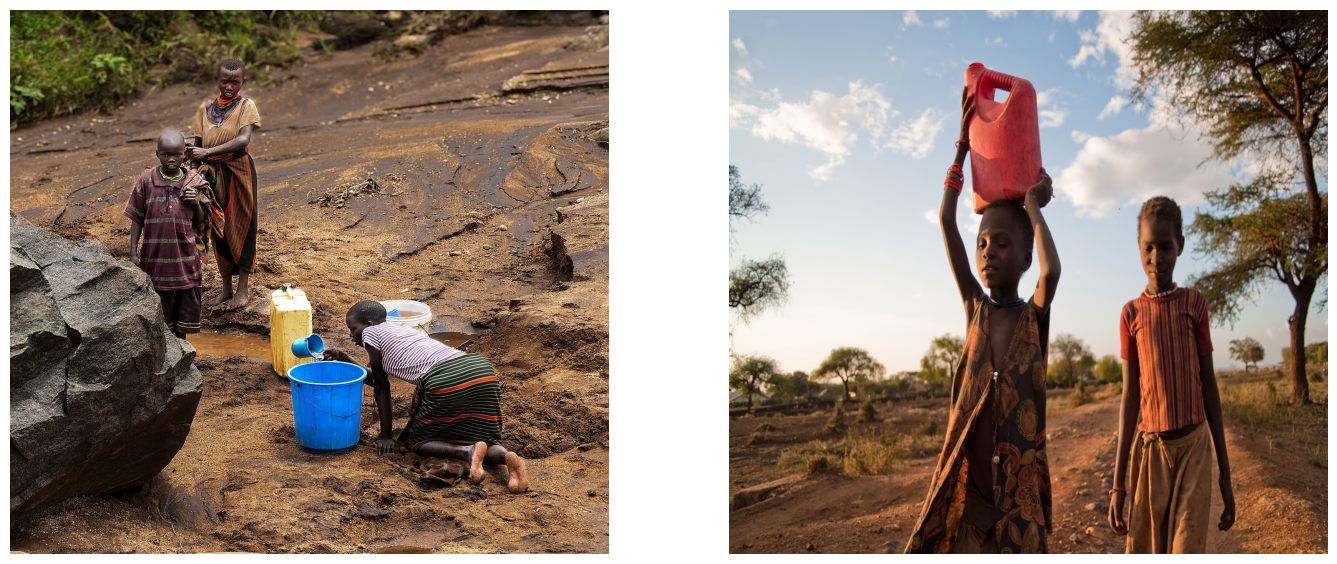

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread("/kaggle/input/datasets/mitchellabonyo/images-data/images/image_7.png")
img2 = mpimg.imread("/kaggle/input/datasets/mitchellabonyo/images-data/images/image_9.png")

plt.figure(figsize=(17,13))

plt.subplot(1,2,1)
plt.imshow(img1, extent=[0, 1100, 0, 1000])  # width=1000, height=1000
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2, extent=[0, 1100, 0, 1000])
plt.axis("off")

plt.show()

It remains unclear whether nutrition outcomes in Karamoja are improving over time when examined systematically using data. This study therefore aims to analyze trends in Global Acute Malnutrition (GAM) across the nine districts of Karamoja using data from two reporting periods: February 2023 – January 2024, and March 2024 – February 2025. 
By using statistical testing, the study seeks to determine whether observed changes in malnutrition levels are statistically significant.


## 2. Data Source and Description

The dataset used in this study was constructed by extracting district-level Global Acute Malnutrition (GAM) values from official reports published under the Integrated Food Security Phase Classification framework for Uganda.

The following reports were used:
* [IPC Uganda Karamoja Acute Malnutrition Report (February 2023 – January 2024)](https://www.ipcinfo.org/ipc-country-analysis/details-map/en/c/1156424/)
* [IPC Uganda Karamoja Acute Malnutrition Report (March 2024 – February 2025)](https://www.ipcinfo.org/ipc-country-analysis/details-map/en/c/1157054/)

The dataset includes nine districts in Karamoja:

1. Abim
2. Amudat
3. Kaabong
4. Karenga
5. Kotido
6. Moroto
7. Nabilatuk
8. Nakapiripirit
9. Napak

Global Acute Malnutrition (GAM) refers to the **percentage** of children aged 6–59 months who are acutely malnourished, combining both moderate and severe cases.

All nine districts included in the study are recipients of humanitarian aid interventions.

## 3. Load dataset 

In [10]:
import pandas as pd

url = "https://github.com/ninamitchell23/Kujenga_Final_Project/raw/refs/heads/main/karamoja_gam_data.csv"

df = pd.read_csv(url)

df

,District,GAM_2023_2024,GAM_2024_2025
0,Abim,9.8,5.7
1,Amudat,14.9,17.3
2,Kaabong,23.5,16.9
3,Karenga,14.0,13.2
4,Kotido,19.9,12.4
5,Moroto,15.0,13.8
6,Nabilatuk,17.8,6.6
7,Nakapiripirit,16.9,8.5
8,Napak,14.2,8.7


## Statistical Testing (Paired t-test) 

### The Problem

Although all nine districts in Karamoja receive humanitarian aid, it remains unclear whether nutrition outcomes are improving over time.

From the data, Global Acute Malnutrition (GAM) appears to change between reporting periods. However, visual differences alone are not enough to conclude whether a real improvement has occurred, as such changes may be due to random variation or external factors.

To answer this rigorously, a statistical test is required.

### Why a Statistical Test?

Simply comparing averages does not prove that a real change has occurred.

A statistical test helps determine whether the observed difference in GAM is likely due to chance or represents a meaningful change in nutrition outcomes.

### Hypotheses

We test whether GAM has significantly changed between:

- February 2023 – January 2024  
- March 2024 – February 2025  

**Null Hypothesis (H₀):**  
There is no significant difference in GAM between the two periods.

**Alternative Hypothesis (H₁):**  
There is a significant difference in GAM between the two periods.

### Significance Level

A significance level of **α = 0.05** is used.

This means we accept a 5% risk of incorrectly rejecting the null hypothesis. If the p-value is less than 0.05, the result is considered statistically significant.

### Why a Paired t-test?

A paired t-test is used because:

- The same districts are observed in both periods  
- The data is paired (before vs after comparison)  
- This allows us to measure change within each district

### 4. Running the Test in Python 

In [11]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(df["GAM_2023_2024"], df["GAM_2024_2025"])

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 3.344857660209673
P-value: 0.01015757962236301


### 5. Critical Value Calculation

In [12]:
from scipy.stats import t

# degrees of freedom
dfree = len(df["GAM_2023_2024"]) - 1

alpha = 0.05

# two-sided test
critical_value = t.ppf(1 - alpha/2, dfree)

print("Critical value:", critical_value)

Critical value: 2.306004135204166


### Decision Rule

- If **p-value < 0.05** → Reject H₀  
- If **|t-statistic| > critical value** → Reject H₀  

Otherwise, fail to reject the null hypothesis.

### 6. Interpretation

A paired t-test was conducted to determine whether there is a statistically significant difference in Global Acute Malnutrition (GAM) between the periods February 2023–January 2024 and March 2024–February 2025 across the nine districts of Karamoja.

Using a significance level of **α = 0.05**, the results show that the p-value is less than 0.05. Therefore, the null hypothesis is rejected, indicating that the observed difference in GAM is statistically significant.

This conclusion is supported by the critical value approach, where the absolute value of the t-statistic exceeds the critical threshold.

The results indicate a **decrease in GAM levels** in the most recent period, suggesting an improvement in nutrition outcomes across the districts.

However, this improvement may not always be clearly visible at the community level and may be influenced by other factors such as climate conditions, food availability, disease, and socioeconomic conditions.

Overall, the analysis demonstrates the importance of using statistical methods to detect meaningful changes that may not be immediately apparent through observation alone.

### 7. Visualizations

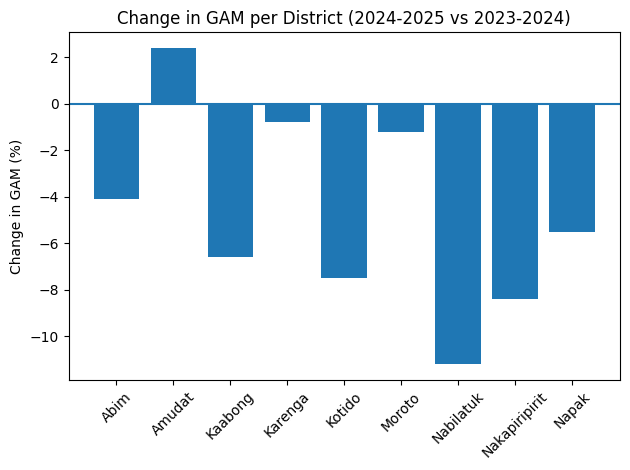

In [13]:
df["Difference"] = df["GAM_2024_2025"] - df["GAM_2023_2024"]

plt.figure()
plt.bar(df["District"], df["Difference"])

plt.axhline(0)  # important reference line

plt.xticks(rotation=45)
plt.ylabel("Change in GAM (%)")
plt.title("Change in GAM per District (2024-2025 vs 2023-2024)")

plt.tight_layout()
plt.show()

Above is a difference plot. Out of nine districts, eight saw malnutrition rates go down between 2023–2024 and 2024–2025. Nabilatuk improved the most, dropping by about 11 percentage points. Amudat was the only district that got worse, with malnutrition rising by about 2.5%. This shows that while most of Karamoja is heading in the right direction, not every district is improving at the same pace.

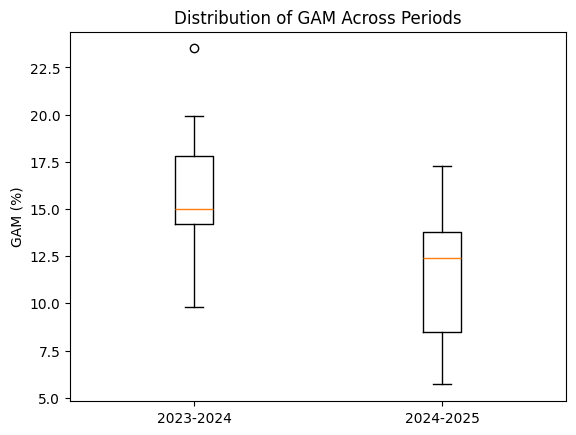

In [14]:
import matplotlib.pyplot as plt

plt.figure()

plt.boxplot([
    df["GAM_2023_2024"],
    df["GAM_2024_2025"]
])

plt.xticks([1, 2], ["2023-2024", "2024-2025"])
plt.ylabel("GAM (%)")
plt.title("Distribution of GAM Across Periods")

plt.show()

The boxplot above shows a visible decline in Global Acute Malnutrition (GAM) rates across Karamoja's nine districts between 2023–2024 and 2024–2025. The median dropped from approximately 15.3% to 12.3%, with the overall spread of values also narrowing, indicating more consistent improvement across districts. The outlier visible in 2023–2024 (≈23.5%) disappears in the following period, suggesting that even the most severely affected district recorded meaningful progress.

# Conclusion

The objective of this research was to assess whether nutrition outcomes are improving in Karamoja over time.

Data for the analysis were drawn from Global Acute Malnutrition (GAM) figures for each of the two time periods investigated (Feb 2023 – Jan 2024; Mar 2024 – Feb 2025) at the district level.

A paired t-test was used to determine whether the changes seen in the GAM figures were statistically significant. The results showed that the GAM figures had significantly decreased across the different districts; therefore, statistically, nutritional outcomes are improving in Karamoja.

Importantly, the findings highlight a gap between statistical evidence and lived experience. While the data suggests improvement, observations from communities such as Napak indicate that challenges remain visible and persistent. This underscores the need to combine quantitative analysis with on-the-ground perspectives when evaluating development outcomes. Also, these findings help us appreciate the work being done to combat malnutrition in the sub-region.

Overall, this study shows the value of statistical methods in uncovering trends that may not be immediately apparent, while also emphasizing the importance of contextual understanding in interpreting those results. Future research could build on this work by incorporating additional variables and longer time series data to better understand the drivers of malnutrition and the effectiveness of interventions in Karamoja.


# *Not forgotten, but not yet transformed: the reality of Karamoja.*

# References

* https://www.ipcinfo.org/ipc-country-analysis/details-map/en/c/1156424/

* https://www.ipcinfo.org/ipc-country-analysis/details-map/en/c/1157054/

* Catley, A., Stites, E., Ayele, M., & Arasio, R. L. (2021). Introducing pathways to resilience in the
Karamoja Cluster. *Pastoralism*, 11(1), 28. https://doi.org/10.1186/s13570-021-00214-4

* FEWS NET. (2016). *Karamoja, Uganda: Enhanced market analysis 2016*. Famine Early Warning Systems
Network.

* FEWS NET. (2019). *Uganda food security outlook*. Famine Early Warning Systems Network.

* IGAD Resilience Analysis Unit, FAO, UNDP, UNICEF, & WFP. (2015). *Resilience context analysis:
Resilience to food insecurity and malnutrition in Karamoja, Uganda*. World Food Programme.
https://www.wfp.org/publications/uganda-resilience-food-insecurity-malnutrition-karamoja-april-2015

* Mubiru, D. N., Radeny, M., Kyazze, F. B., Zziwa, A., Lwasa, J., Kinyangi, J., & Mungai, C. (2018).
Climate trends and farmer perceptions of climate change in Karamoja subregion of Uganda.
*International Journal of Climate Change Strategies and Management*, 10(4), 630–648.
https://doi.org/10.1108/IJCCSM-12-2016-0179

* Peteris, A., Owino, A., Nanteza, A., Sundal, M., Lönnqvist, A., Wangila, P., & Ekesa, B. (2022).
Livelihood dynamics and challenges to wellbeing in the drylands of rural East Africa — the Drylands
Transform study population in the Karamoja border region. *Frontiers in Public Health*.
https://pmc.ncbi.nlm.nih.gov/articles/PMC12024496/

* ReliefWeb / London School of Economics. (2021). *Karamoja region: Sustainable agriculture to fight
food insecurity in Uganda*.
https://reliefweb.int/report/uganda/karamoja-region-sustainable-agriculture-fight-food-insecurity-uganda

* Ververs, M., Ariti, C., & Myatt, M. (2016). Agricultural land use change in Karamoja region, Uganda.
*Land Use Policy*, 63, 316–327. https://doi.org/10.1016/j.landusepol.2016.12.014